# FuzzyTreeRegressor Demo

A decision tree where splits use **fuzzy membership functions** instead of hard thresholds.
Each observation partially belongs to both children of every split, so the final prediction
is a smooth weighted average over all reachable leaves.

This notebook shows:
1. **Synthetic surface** — 3D decision surfaces vs sklearn (gplearn example)
2. **Rossmann store sales** — real-world accuracy + feature contribution waterfall

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils.validation import check_random_state
from fuzzydtree import FuzzyTreeRegressor

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## 1. Synthetic surface

Same setup as the [gplearn symbolic-regression example](https://gplearn.readthedocs.io/en/latest/examples.html):

$$y = X_0^2 - X_1^2 + X_1 - 1$$

Ground-truth surface on a grid, plus 100 random training points from $[-1,1]^2$.

In [20]:
# Ground truth
x0 = np.arange(-1, 1, .1)
x1 = np.arange(-1, 1, .1)
x0, x1 = np.meshgrid(x0, x1)
y_truth = x0**2 - x1**2 + x1 - 1

# Training and test samples
rng = check_random_state(0)
X_train = rng.uniform(-1, 1, size=(1000, 2))
y_train = X_train[:, 0]**2 - X_train[:, 1]**2 + X_train[:, 1] - 1
X_test = rng.uniform(-1, 1, size=(100, 2))
y_test = X_test[:, 0]**2 - X_test[:, 1]**2 + X_test[:, 1] - 1

### Fit models

In [21]:
est_fuzzy = FuzzyTreeRegressor(max_depth=5, optimize_leaf_values=True, leaf_l2=0.1)
est_fuzzy.fit(X_train, y_train)

est_tree = DecisionTreeRegressor(max_depth=5)
est_tree.fit(X_train, y_train)

est_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)
est_rf.fit(X_train, y_train)

print(f'FuzzyTree  R\u00b2 = {est_fuzzy.score(X_test, y_test):.6f}  '
      f'(leaves={est_fuzzy.n_leaves_}, depth={est_fuzzy.depth_})')
print(f'Tree       R\u00b2 = {est_tree.score(X_test, y_test):.6f}')
print(f'RF         R\u00b2 = {est_rf.score(X_test, y_test):.6f}')

FuzzyTree  R² = 0.988171  (leaves=32, depth=5)
Tree       R² = 0.931319
RF         R² = 0.963953


### Decision surfaces

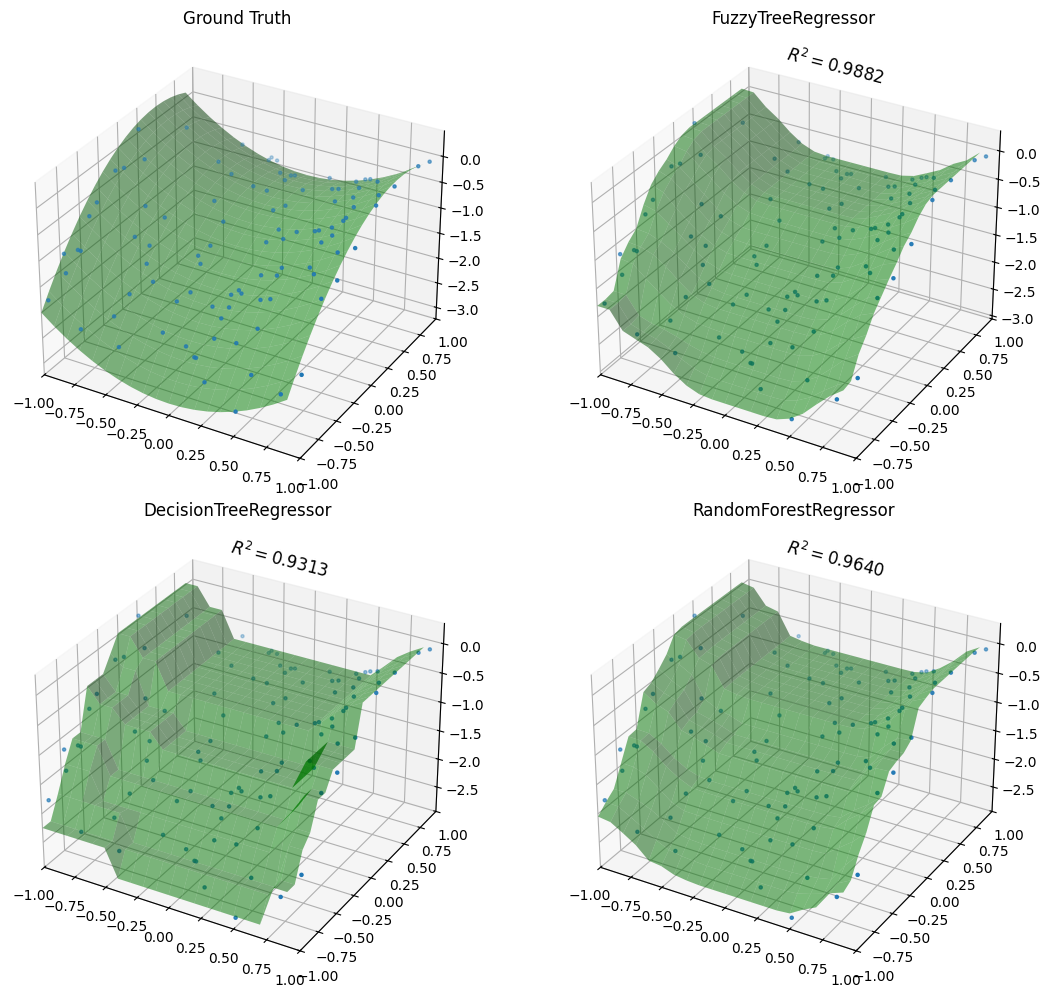

In [23]:
X_grid = np.c_[x0.ravel(), x1.ravel()]

y_fuzzy = est_fuzzy.predict(X_grid).reshape(x0.shape)
y_tree = est_tree.predict(X_grid).reshape(x0.shape)
y_rf = est_rf.predict(X_grid).reshape(x0.shape)

fig = plt.figure(figsize=(12, 10))

for i, (y_surf, score, title) in enumerate([
    (y_truth, None, 'Ground Truth'),
    (y_fuzzy, est_fuzzy.score(X_test, y_test), 'FuzzyTreeRegressor'),
    (y_tree, est_tree.score(X_test, y_test), 'DecisionTreeRegressor'),
    (y_rf, est_rf.score(X_test, y_test), 'RandomForestRegressor'),
]):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.plot_surface(x0, x1, y_surf, rstride=1, cstride=1,
                    color='green', alpha=0.5)
    ax.scatter(X_test[:, 0], X_test[:, 1], y_test, s=5)
    if score is not None:
        ax.text(-0.7, 1, 0.2, f'$R^2 = {score:.4f}$', 'x', fontsize=12)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Feature importances

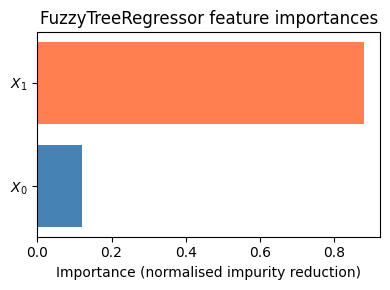

In [5]:
feature_names = ['$X_0$', '$X_1$']
imp = est_fuzzy.feature_importances_

fig, ax = plt.subplots(figsize=(4, 3))
ax.barh(feature_names, imp, color=['steelblue', 'coral'])
ax.set_xlabel('Importance (normalised impurity reduction)')
ax.set_title('FuzzyTreeRegressor feature importances')
plt.tight_layout()
plt.show()

### Tree structure

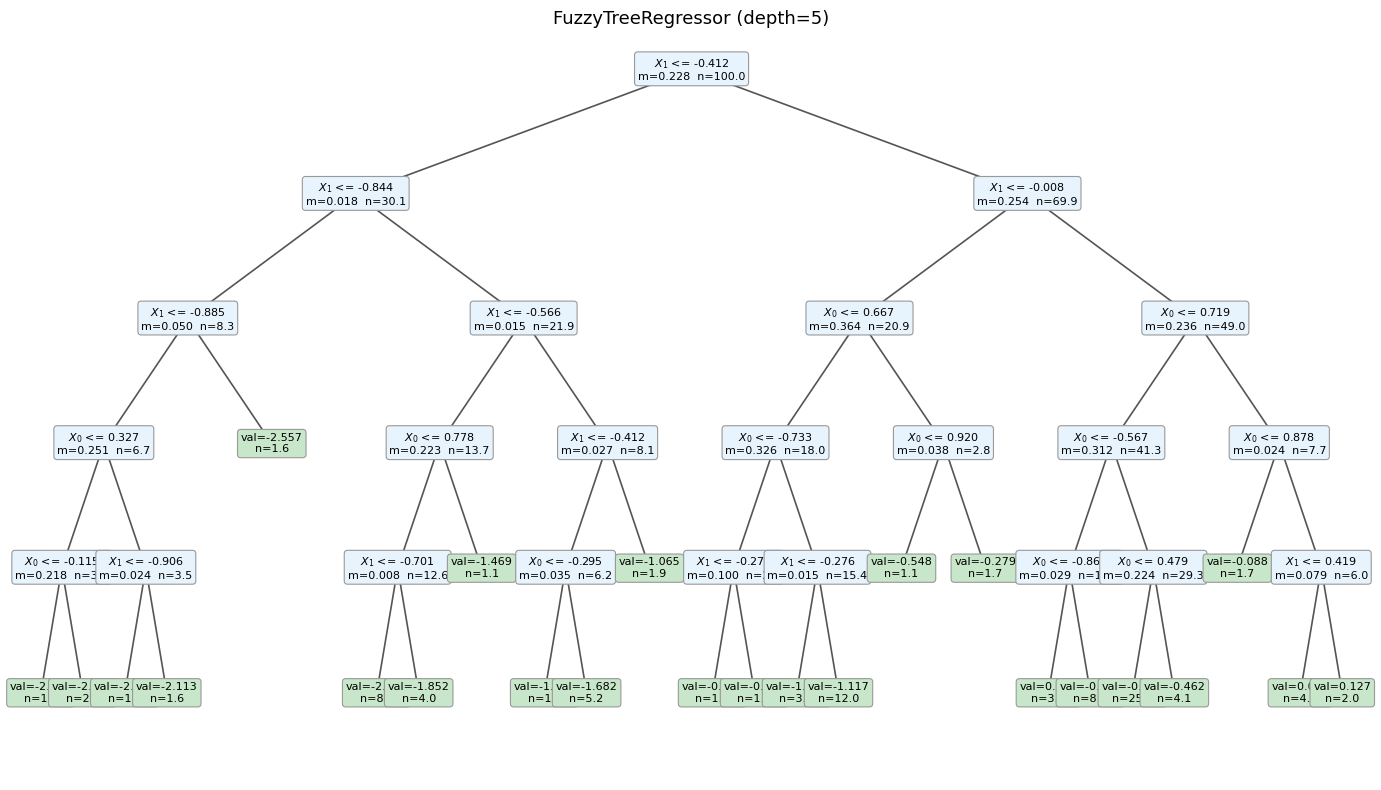

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
est_fuzzy.plot_tree(feature_names=['$X_0$', '$X_1$'], ax=ax, fontsize=8)
ax.set_title('FuzzyTreeRegressor (depth=5)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Rossmann Store 1 — real-world regression

Daily sales prediction for a single retail store. We compare FuzzyTreeRegressor
against sklearn's DecisionTree and LightGBM on point-prediction accuracy,
then show waterfall explanations for individual predictions.

In [7]:
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

df = pd.read_csv('data/store1.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Dayofweek'] = df['Date'].dt.dayofweek
df['Dayofyear'] = df['Date'].dt.dayofyear
df['Weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Closed'] = (df['Dayofweek'] == 6).astype(int)

features = ['Dayofweek', 'Dayofyear', 'Weekofyear', 'Year', 'Month', 'Day',
            'Promo', 'StateHoliday', 'SchoolHoliday', 'Closed']
target = 'Sales'

train = df[df['Date'] < '2015-06-01']
test  = df[df['Date'] >= '2015-06-01']

X_tr, y_tr = train[features].values, train[target].values
X_te, y_te = test[features].values, test[target].values
print(f'Train: {len(train)}   Test: {len(test)}')

Train: 881   Test: 61


### Train & compare

In [16]:
ft = FuzzyTreeRegressor(max_depth=10, min_samples_leaf=5)
ft.fit(X_tr, y_tr)

dt = DecisionTreeRegressor(max_depth=6)
dt.fit(X_tr, y_tr)

lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6,
                      min_child_samples=5, random_state=42, verbose=-1)
lgbm.fit(X_tr, y_tr)

models = [
    ('FuzzyTreeRegressor', ft),
    ('DecisionTree',       dt),
    ('LightGBM',           lgbm),
]

print(f'{"Model":<25} {"RMSE":>10} {"R2":>10}')
print('-' * 47)
for name, m in models:
    pred = m.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = m.score(X_te, y_te)
    print(f'{name:<25} {rmse:>10.1f} {r2:>10.4f}')

Model                           RMSE         R2
-----------------------------------------------
FuzzyTreeRegressor             340.3     0.9608
DecisionTree                   401.3     0.9455
LightGBM                       374.2     0.9527


d:\Users\guyko\anaconda3\envs\distreg\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Users\guyko\anaconda3\envs\distreg\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Predictions — time series view

d:\Users\guyko\anaconda3\envs\distreg\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


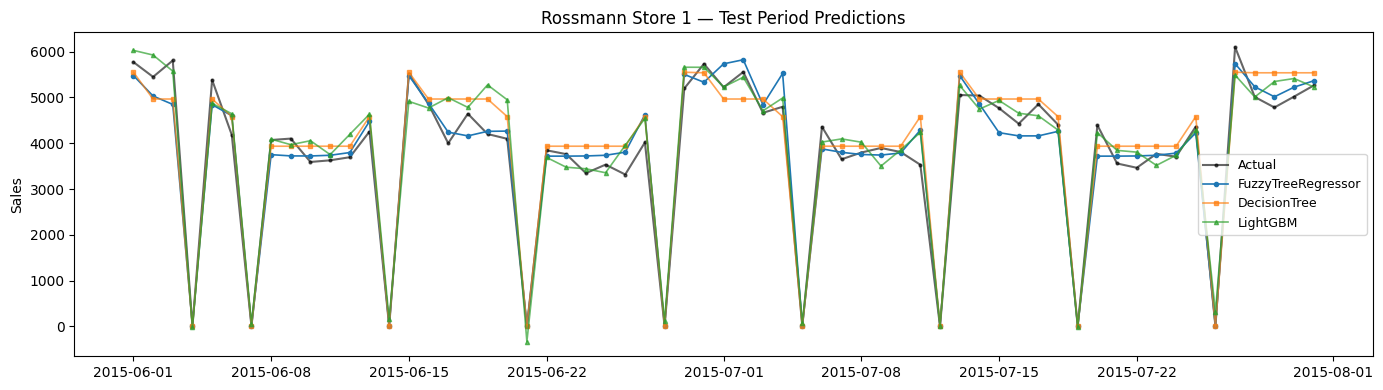

In [17]:
dates = test['Date'].values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, y_te, 'k.-', ms=4, alpha=0.6, label='Actual')
ax.plot(dates, ft.predict(X_te), 'o-', ms=3, lw=1.2, label='FuzzyTreeRegressor')
ax.plot(dates, dt.predict(X_te), 's-', ms=3, lw=1.2, alpha=0.7, label='DecisionTree')
ax.plot(dates, lgbm.predict(X_te), '^-', ms=3, lw=1.2, alpha=0.7, label='LightGBM')
ax.set_ylabel('Sales')
ax.set_title('Rossmann Store 1 \u2014 Test Period Predictions')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Feature contribution waterfall

The `explain_prediction` method decomposes a single prediction into a baseline
(training mean) plus per-feature contributions. This shows **why** the model
predicts what it does for a specific day.

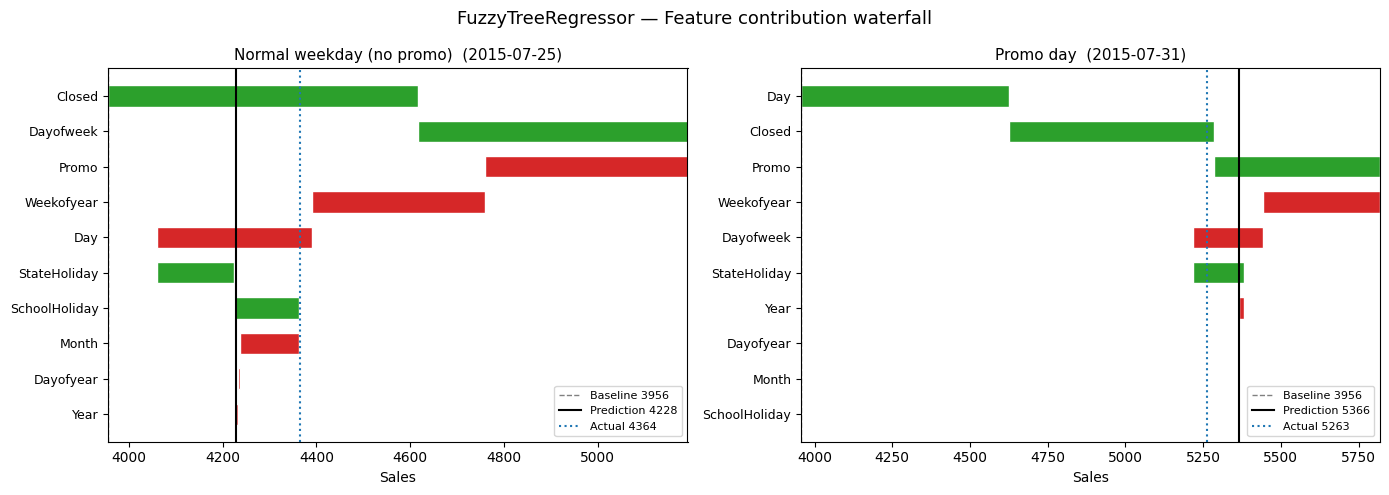

In [18]:
# Pick two contrasting days from the test set
closed_col = features.index('Closed')
promo_col = features.index('Promo')

idx_open = next(i for i in range(len(X_te))
                if X_te[i, closed_col] == 0 and X_te[i, promo_col] == 0)
idx_promo = next(i for i in range(len(X_te))
                 if X_te[i, closed_col] == 0 and X_te[i, promo_col] == 1)

cases = [
    (idx_open,  'Normal weekday (no promo)'),
    (idx_promo, 'Promo day'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (idx, label) in zip(axes, cases):
    exp = ft.explain_prediction(X_te[idx], feature_names=features)
    contribs = exp['feature_contributions']
    names = list(contribs.keys())
    vals = np.array([contribs[n] for n in names])

    # Waterfall bars
    starts = np.zeros(len(vals))
    running = exp['baseline']
    for i, v in enumerate(vals):
        starts[i] = running
        running += v

    colors = ['#2ca02c' if v >= 0 else '#d62728' for v in vals]
    ax.barh(range(len(names)), vals, left=starts, color=colors,
            edgecolor='white', height=0.6)

    ax.axvline(exp['baseline'], color='gray', ls='--', lw=1,
               label=f'Baseline {exp["baseline"]:.0f}')
    ax.axvline(exp['prediction'], color='black', ls='-', lw=1.5,
               label=f'Prediction {exp["prediction"]:.0f}')
    ax.axvline(y_te[idx], color='C0', ls=':', lw=1.5,
               label=f'Actual {y_te[idx]:.0f}')

    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Sales')
    date_str = pd.Timestamp(test['Date'].values[idx]).strftime('%Y-%m-%d')
    ax.set_title(f'{label}  ({date_str})', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('FuzzyTreeRegressor \u2014 Feature contribution waterfall', fontsize=13)
plt.tight_layout()
plt.show()

### Leaf-level breakdown

For deeper inspection: which leaves does the sample reach, with what weights,
and how does the value evolve step-by-step down the tree?

In [19]:
for idx, label in cases:
    exp = ft.explain_prediction(X_te[idx], feature_names=features)
    leaves = exp['leaves']
    date_str = pd.Timestamp(test['Date'].values[idx]).strftime('%Y-%m-%d')

    print('=' * 90)
    print(f'{label}  ({date_str})')
    print(f'Baseline: {exp["baseline"]:.1f}   Prediction: {exp["prediction"]:.1f}   '
          f'Actual: {y_te[idx]:.1f}   Leaves reached: {len(leaves)}')
    print()
    print(f'  {"#":>3}  {"Leaf val":>9}  {"Weight":>8}  {"Contrib":>9}  {"Depth":>5}')
    print(f'  ---  ---------  --------  ---------  -----')
    for j, leaf in enumerate(leaves[:10]):
        print(f'  {j+1:>3}  {leaf["value"]:>9.1f}  {leaf["weight"]:>8.4f}  '
              f'{leaf["contribution"]:>+9.1f}  {len(leaf["path"]):>5}')
    if len(leaves) > 10:
        print(f'  ... ({len(leaves) - 10} more leaves)')
    print(f'\n  Sum of weights = {sum(l["weight"] for l in leaves):.6f}')
    print()

Normal weekday (no promo)  (2015-07-25)
Baseline: 3956.4   Prediction: 4228.1   Actual: 4364.0   Leaves reached: 69

    #   Leaf val    Weight    Contrib  Depth
  ---  ---------  --------  ---------  -----
    1     4252.5    0.9279    +3945.9     10
    2     3679.6    0.0448     +164.7      9
    3     4370.2    0.0244     +106.6     10
    4     3718.4    0.0029      +10.8     10
    5     5008.1    0.0000       +0.0      7
    6     4346.9    0.0000       +0.0      7
    7     4976.9    0.0000       +0.0     10
    8     4104.7    0.0000       +0.0     10
    9     3784.0    0.0000       +0.0     10
   10     3612.4    0.0000       +0.0     10
  ... (59 more leaves)

  Sum of weights = 1.000000

Promo day  (2015-07-31)
Baseline: 3956.4   Prediction: 5365.9   Actual: 5263.0   Leaves reached: 69

    #   Leaf val    Weight    Contrib  Depth
  ---  ---------  --------  ---------  -----
    1     5369.0    0.9330    +5009.2      7
    2     4260.2    0.0380     +161.9      9
    3    